In [2]:
import numpy as np
from forward_propagater import *
from input_writer import glowDischargeConfigs

import matplotlib.pyplot as plt
%matplotlib inline

(1e-23, 1e-13)

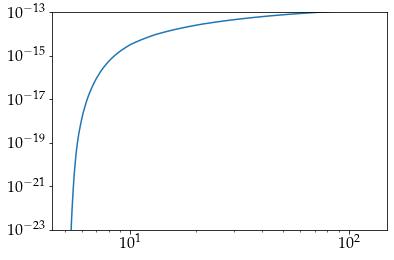

In [9]:
data=[[0.0   ,  1.0E-27  ],
      [5.16E+00,1.39E-27],
            [5.24E+00	,	2.91E-26],
            [5.29E+00	,	4.04E-25],
            [5.34E+00	,	3.99E-24],
            [5.38E+00	,	2.97E-23],
            [5.43E+00	,	1.74E-22],
            [5.48E+00	,	8.37E-22],
            [5.53E+00	,	3.37E-21],
            [5.59E+00	,	1.17E-20],
            [5.65E+00	,	3.57E-20],
            [5.72E+00	,	9.78E-20],
            [5.80E+00	,	2.44E-19],
            [5.89E+00	,	5.59E-19],
            [5.98E+00	,	1.19E-18],
            [6.08E+00	,	2.39E-18],
            [6.19E+00	,	4.53E-18],
            [6.30E+00	,	8.17E-18],
            [6.42E+00	,	1.41E-17],
            [6.55E+00	,	2.35E-17],
            [6.69E+00	,	3.78E-17],
            [6.83E+00	,	5.90E-17],
            [6.98E+00	,	8.97E-17],
            [7.15E+00	,	1.33E-16],
            [7.32E+00	,	1.95E-16],
            [7.51E+00	,	2.79E-16],
            [7.72E+00	,	3.94E-16],
            [7.94E+00	,	5.49E-16],
            [8.19E+00	,	7.56E-16],
            [8.47E+00	,	1.03E-15],
            [8.78E+00	,	1.40E-15],
            [9.14E+00	,	1.87E-15],
            [9.55E+00	,	2.50E-15],
            [1.00E+01	,	3.31E-15],
            [1.06E+01	,	4.35E-15],
            [1.13E+01	,	5.69E-15],
            [1.21E+01	,	7.40E-15],
            [1.30E+01	,	9.55E-15],
            [1.42E+01	,	1.22E-14],
            [1.56E+01	,	1.55E-14],
            [1.73E+01	,	1.95E-14],
            [1.93E+01	,	2.43E-14],
            [2.17E+01	,	2.99E-14],
            [2.47E+01	,	3.63E-14],
            [2.83E+01	,	4.36E-14],
            [3.26E+01	,	5.17E-14],
            [3.78E+01	,	6.06E-14],
            [4.41E+01	,	7.02E-14],
            [5.17E+01	,	8.03E-14],
            [6.10E+01	,	9.08E-14],
            [7.24E+01	,	1.02E-13],
            [8.67E+01	,	1.13E-13],
            [1.05E+02	,	1.23E-13],
            [1.28E+02	,	1.34E-13]]
data = np.array(data)

plt.figure(1)
plt.loglog(data[:,0],data[:,1])
plt.ylim([1e-23, 1e-13])

## Write an bolsig input file with a standard LXCat cross section dataset

In [2]:
inputFile = 'input.test.dat'
config = glowDischargeConfigs['reaction300K'] # this is bolsig solver option configuration.
crsFile = './crs/Biagi.txt'
outputFile = 'output.test.dat'
writeInputFile(inputFile, config, crsFile, outputFile, noscreen=False)

## Run bolsig with this input file

In [3]:
import subprocess
command = "./bolsigminus %s" %(inputFile)

subprocess.check_call(command,shell=True)

READCOLLISIONS
 Ar
./crs/Biagi.txt
 C1    Ar    Elastic                                             
 C2    Ar    Excitation    11.55 eV                              
 C3    Ar    Excitation    11.62 eV                              
 C4    Ar    Excitation    11.72 eV                              
 C5    Ar    Excitation    11.83 eV                              
 C6    Ar    Excitation    12.91 eV                              
 C7    Ar    Excitation    13.08 eV                              
 C8    Ar    Excitation    13.10 eV                              
 C9    Ar    Excitation    13.15 eV                              
 C10   Ar    Excitation    13.17 eV                              
 C11   Ar    Excitation    13.27 eV                              
 C12   Ar    Excitation    13.28 eV                              
 C13   Ar    Excitation    13.30 eV                              
 C14   Ar    Excitation    13.33 eV                              
 C15   Ar    Excitation    13.48 eV      

R199  4524. Td    49.7 eV
R200  4544. Td    50.0 eV
SAVERESULTS
output.test.dat
FINISHED


0

## Read reaction coefficient from bolsig output

Default input variable is set to be electron mean energy (eV).

In [4]:
collisionTypes = ['Ionization'] + 4 * ['Excitation']
collisionEnergies = [15.76, 11.55, 11.62, 11.72, 11.83]
deltaE = 0.05

rateTables = []
for k, colType in enumerate(collisionTypes):
    rateTables += [np.copy(getReactionFromBolsig(outputFile, colType, collisionEnergies[k], deltaERange = deltaE))]

Input variable: Mean energy (eV)
Output collision type: Ionization
Output reaction energy: 1.57600000E+01
Input variable: Mean energy (eV)
Output collision type: Excitation
Output reaction energy: 1.15500000E+01
Input variable: Mean energy (eV)
Output collision type: Excitation
Output reaction energy: 1.16200000E+01
Input variable: Mean energy (eV)
Output collision type: Excitation
Output reaction energy: 1.17200000E+01
Input variable: Mean energy (eV)
Output collision type: Excitation
Output reaction energy: 1.18300000E+01


[[5.000e-02 0.000e+00]
 [3.010e-01 0.000e+00]
 [5.520e-01 0.000e+00]
 [8.030e-01 0.000e+00]
 [1.054e+00 0.000e+00]
 [1.305e+00 0.000e+00]
 [1.556e+00 0.000e+00]
 [1.807e+00 0.000e+00]
 [2.058e+00 0.000e+00]
 [2.309e+00 0.000e+00]
 [2.560e+00 0.000e+00]
 [2.811e+00 0.000e+00]
 [3.062e+00 0.000e+00]
 [3.313e+00 0.000e+00]
 [3.564e+00 0.000e+00]
 [3.815e+00 0.000e+00]
 [4.066e+00 0.000e+00]
 [4.317e+00 0.000e+00]
 [4.568e+00 0.000e+00]
 [4.819e+00 0.000e+00]
 [5.070e+00 5.788e-28]
 [5.321e+00 2.470e-23]
 [5.572e+00 2.357e-20]
 [5.823e+00 5.761e-19]
 [6.074e+00 4.181e-18]
 [6.325e+00 1.712e-17]
 [6.576e+00 4.929e-17]
 [6.827e+00 1.111e-16]
 [7.078e+00 2.100e-16]
 [7.329e+00 3.490e-16]
 [7.580e+00 5.291e-16]
 [7.831e+00 7.482e-16]
 [8.082e+00 1.004e-15]
 [8.333e+00 1.293e-15]
 [8.584e+00 1.613e-15]
 [8.835e+00 1.962e-15]
 [9.086e+00 2.335e-15]
 [9.337e+00 2.732e-15]
 [9.588e+00 3.151e-15]
 [9.839e+00 3.589e-15]
 [1.009e+01 4.044e-15]
 [1.034e+01 4.514e-15]
 [1.059e+01 4.999e-15]
 [1.084e+01

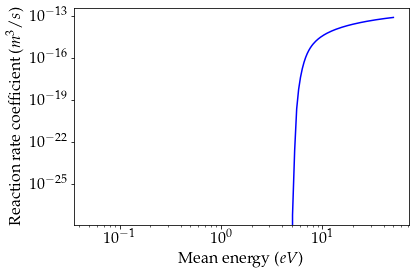

In [5]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})
colors = ['b','g','darkred','c','mediumpurple','tomato']

plt.figure(1)
for k in range(1):
    plt.loglog(rateTables[k][:,0], rateTables[k][:,1], '-', color=colors[k])
plt.xlabel('Mean energy ($eV$)')
plt.ylabel('Reaction rate coefficient ($m^3/s$)')
print(rateTables[0])

## Read sample reaction rates from the binary file

72


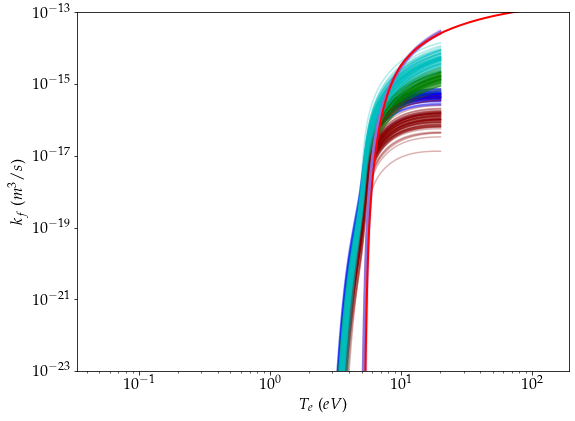

In [11]:
import input_writer as iw
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})
colors = ['b','g','darkred','c','mediumpurple','tomato']

N300 = iw.reaction300K['RUNSERIES'][3]
E300 = np.linspace( np.log(iw.reaction300K['RUNSERIES'][1]), np.log(iw.reaction300K['RUNSERIES'][2]), N300)

excite300 = np.fromfile('./glow-discharge/data/reaction300K.excite.dat')
excite300 = np.reshape(excite300,[int(len(excite300)/14/N300),14,N300])

ion300 = np.fromfile('./glow-discharge/data/reaction300K.ion.dat')
ion300 = np.reshape(ion300,[int(len(ion300)/N300),N300])

Te300 = np.fromfile('./glow-discharge/data/reaction300K.Te.dat')
Te300 = np.reshape(Te300,[int(len(Te300)/N300),N300])

Nsample = Te300.shape[0]
print(Nsample)

plt.figure(1)
for ex in range(4):
    for k in range(Nsample):
        plt.loglog(Te300[k,:], excite300[k,ex,:],'-', color=colors[ex],alpha=0.3)
for k in range(Nsample):
    plt.loglog(Te300[k,:], ion300[k,:],'-', color=colors[4],alpha=0.3)
plt.loglog(data[:,0],data[:,1],'-r',linewidth=2)
plt.xlabel('$T_e$ ($eV$)')
plt.ylabel('$k_f$ ($m^3/s$)')
plt.ylim([1e-23, 1e-13])
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(9, 7)
    
# plt.figure(5)
# for k in range(Nsample):
#     plt.loglog(Te300[k,:], ion300[k,:],'-', color='peru',alpha=0.3)
# plt.xlabel('$T_e$ ($eV$)')
# plt.ylabel('$k_f$ ($m^3/s$)')

72


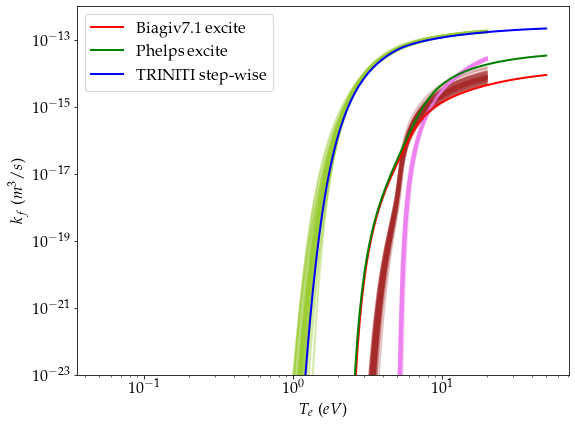

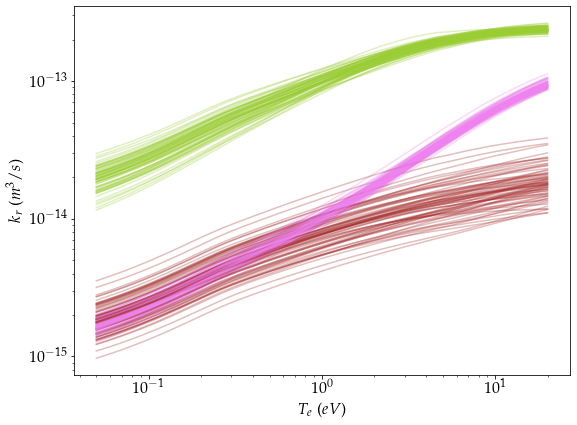

In [22]:
import input_writer as iw
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})
colors = ['b','g','darkred','c','mediumpurple','tomato']

N300 = iw.reaction300K['RUNSERIES'][3]
E300 = np.linspace( np.log(iw.reaction300K['RUNSERIES'][1]), np.log(iw.reaction300K['RUNSERIES'][2]), N300)

excite300 = np.fromfile('./glow-discharge/data/reaction300K.excite.dat')
excite300 = np.reshape(excite300,[int(len(excite300)/14/N300),14,N300])

ion300 = np.fromfile('./glow-discharge/data/reaction300K.ion.dat')
ion300 = np.reshape(ion300,[int(len(ion300)/N300),N300])

step_ion300 = np.fromfile('./glow-discharge/data/reaction300K.step_ion.dat')
step_ion300 = np.reshape(step_ion300,[int(len(step_ion300)/N300),N300])

Te300 = np.fromfile('./glow-discharge/data/reaction300K.Te.dat')
Te300 = np.reshape(Te300,[int(len(Te300)/N300),N300])

excite_sum = np.zeros([excite300.shape[0], N300])
for k in range(4):
    excite_sum += np.squeeze(excite300[:,k,:])
    
excite_r = np.fromfile('./glow-discharge/data/reverse300K.excite.dat')
excite_r = np.reshape(excite_r,[int(len(excite_r)/14/N300),14,N300])

ion_r = np.fromfile('./glow-discharge/data/reverse300K.ion.dat')
ion_r = np.reshape(ion_r,[int(len(ion_r)/N300),N300])

step_ion_r = np.fromfile('./glow-discharge/data/reverse300K.step_ion.dat')
step_ion_r = np.reshape(step_ion_r,[int(len(step_ion_r)/N300),N300])

Te_r = np.fromfile('./glow-discharge/data/reverse300K.Te.dat')
Te_r = np.reshape(Te_r,[int(len(Te_r)/N300),N300])

excite_r_sum = np.zeros([excite_r.shape[0], N300])
for k in range(4):
    excite_r_sum += np.squeeze(excite_r[:,k,:])

Nsample = Te300.shape[0]
print(Nsample)

outputFilename = "./output/datasets/Biagi_v7.1+step.dat"
output = bolsigOutput(outputFilename)
Te0 = output.outputs[3].data[:,1]
dataType = output.typeDictS2I['C2']
rateExcite0 = output.outputs[dataType].data[:,1]

outputFilename = "./output/datasets/Phelps+step.dat"
output = bolsigOutput(outputFilename)
Te1 = output.outputs[3].data[:,1]
dataType = output.typeDictS2I['C2']
rateExcite1 = output.outputs[dataType].data[:,1]

outputFilename = "./output/datasets/Biagi+step.dat"
output = bolsigOutput(outputFilename)
Te2 = output.outputs[3].data[:,1]
dataType = output.typeDictS2I['C47']
rateIon2 = output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C46']
rateDirectIon2 = output.outputs[dataType].data[:,1]

plt.figure(1)
# for ex in range(4):
#     for k in range(Nsample):
#         plt.loglog(Te300[k,:], excite300[k,ex,:],'-', color=colors[ex],alpha=0.3)
for k in range(Nsample):
    plt.loglog(Te300[k,:], excite_sum[k,:],'-', color='brown',alpha=0.3)
    plt.loglog(Te300[k,:], ion300[k,:],'-', color='violet',alpha=0.3)
    plt.loglog(Te300[k,:], step_ion300[k,:],'-', color='yellowgreen',alpha=0.3)
plt.loglog(Te0, rateExcite0,'-', color='r', linewidth=2.0, label='Biagiv7.1 excite')
plt.loglog(Te1, rateExcite1,'-', color='g', linewidth=2.0, label='Phelps excite')
plt.loglog(Te2, rateIon2,'-', color='b', linewidth=2.0, label='TRINITI step-wise')
# plt.loglog(Te2, rateDirectIon2,'-', linewidth=2.0, label='Biagi ion')
# plt.loglog(data[:,0],data[:,1],'--',linewidth=2, label="Juan's step-wise")
plt.xlabel('$T_e$ ($eV$)')
plt.ylabel('$k_f$ ($m^3/s$)')
plt.ylim([1e-23, 1e-12])
plt.legend()
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(9, 7)
fig.savefig("./ionizations.pdf", dpi=1200)

plt.figure(2)
for k in range(Nsample):
    plt.loglog(Te_r[k,:], excite_r_sum[k,:],'-', color='brown',alpha=0.3)
    plt.loglog(Te_r[k,:], ion_r[k,:],'-', color='violet',alpha=0.3)
    plt.loglog(Te_r[k,:], step_ion_r[k,:],'-', color='yellowgreen',alpha=0.3)
plt.xlabel('$T_e$ ($eV$)')
plt.ylabel('$k_r$ ($m^3/s$)')
# plt.ylim([1e-23, 1e-12])
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(9, 7)
    
# plt.figure(5)
# for k in range(Nsample):
#     plt.loglog(Te300[k,:], ion300[k,:],'-', color='peru',alpha=0.3)
# plt.xlabel('$T_e$ ($eV$)')
# plt.ylabel('$k_f$ ($m^3/s$)')

# dataFilename = './glow-discharge/data/reaction300K.lumped_excite.dat'
# fID = open(dataFilename,'w')
# excite_sum.tofile(fID)
# fID.close()

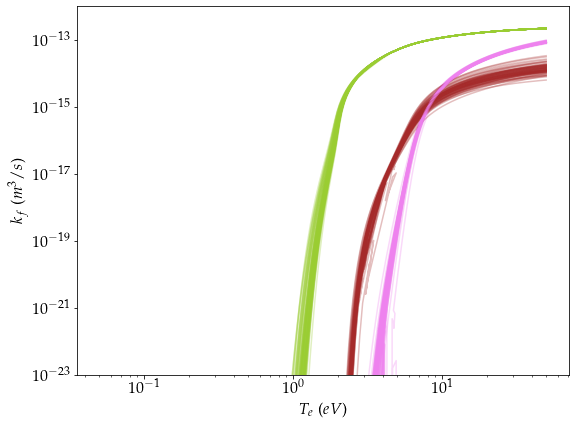

In [37]:
import input_writer as iw
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})
colors = ['b','g','darkred','c','mediumpurple','tomato']

# N300 = iw.reaction300K['RUNSERIES'][3]
# E300 = np.linspace( np.log(iw.reaction300K['RUNSERIES'][1]), np.log(iw.reaction300K['RUNSERIES'][2]), N300)

Nsample = 72
N300 = 200

ion300 = np.fromfile('./glow-discharge/data/reaction300K.ion.dat')
ion300 = np.reshape(ion300,[Nsample,N300])

step_ion300 = np.fromfile('./glow-discharge/data/reaction300K.step_ion.dat')
step_ion300 = np.reshape(step_ion300,[Nsample,N300])

Te300 = np.fromfile('./glow-discharge/data/reaction300K.Te.dat')
Te300 = np.reshape(Te300,[Nsample,N300])

excite300 = np.fromfile('./glow-discharge/data/reaction300K.lumped_excite.dat')
excite300 = np.reshape(excite300,[Nsample,N300])

plt.figure(1)
# for ex in range(4):
#     for k in range(Nsample):
#         plt.loglog(Te300[k,:], excite300[k,ex,:],'-', color=colors[ex],alpha=0.3)
for k in range(Nsample):
    plt.loglog(Te300[k,:], excite300[k,:],'-', color='brown',alpha=0.3)
    plt.loglog(Te300[k,:], ion300[k,:],'-', color='violet',alpha=0.3)
    plt.loglog(Te300[k,:], step_ion300[k,:],'-', color='yellowgreen',alpha=0.3)
plt.xlabel('$T_e$ ($eV$)')
plt.ylabel('$k_f$ ($m^3/s$)')
plt.ylim([1e-23, 1e-12])
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(9, 7)

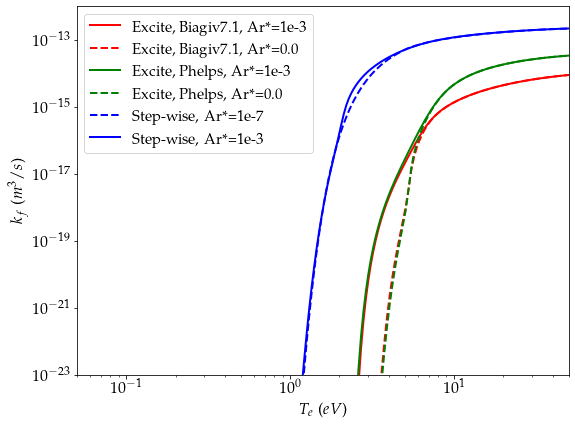

In [51]:
import input_writer as iw
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})
colors = ['b','g','darkred','c','mediumpurple','tomato']

outputFilename = "./output/datasets/Biagi_v7.1+step.dat"
output = bolsigOutput(outputFilename)
Te0 = output.outputs[3].data[:,1]
dataType = output.typeDictS2I['C2']
rateExcite0 = output.outputs[dataType].data[:,1]

outputFilename = "./output/datasets/Biagi.7.1.dat"
output = bolsigOutput(outputFilename)
Te01 = output.outputs[3].data[:,1]
dataType = output.typeDictS2I['C2']
rateExcite01 = output.outputs[dataType].data[:,1]

outputFilename = "./output/datasets/Phelps+step.dat"
output = bolsigOutput(outputFilename)
Te1 = output.outputs[3].data[:,1]
dataType = output.typeDictS2I['C2']
rateExcite1 = output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C4']
rateIon1 = output.outputs[dataType].data[:,1]

outputFilename = "./output/datasets/Phelps.dat"
output = bolsigOutput(outputFilename)
Te11 = output.outputs[3].data[:,1]
dataType = output.typeDictS2I['C2']
rateExcite11 = output.outputs[dataType].data[:,1]


outputFilename = "./output/datasets/Biagi+step.dat"
output = bolsigOutput(outputFilename)
Te2 = output.outputs[3].data[:,1]
dataType = output.typeDictS2I['C47']
rateIon2 = output.outputs[dataType].data[:,1]

plt.figure(1)
plt.loglog(Te0, rateExcite0,'-', color='r', linewidth=2.0, label='Excite, Biagiv7.1, Ar*=1e-3')
plt.loglog(Te01, rateExcite01,'--', color='r', linewidth=2.0, label='Excite, Biagiv7.1, Ar*=0.0')
plt.loglog(Te1, rateExcite1,'-', color='g', linewidth=2.0, label='Excite, Phelps, Ar*=1e-3')
plt.loglog(Te11, rateExcite11,'--', color='g', linewidth=2.0, label='Excite, Phelps, Ar*=0.0')
plt.loglog(Te2, rateIon2,'--', color='b', linewidth=2.0, label='Step-wise, Ar*=1e-7')
plt.loglog(Te1, rateIon1,'-', color='b', linewidth=2.0, label='Step-wise, Ar*=1e-3')
plt.xlabel('$T_e$ ($eV$)')
plt.ylabel('$k_f$ ($m^3/s$)')
plt.xlim([0.05, 50])
plt.ylim([1e-23, 1e-12])
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.legend(loc='upper left', prop={'size': 15})

# fig.savefig("./lumped_state.sensitivity.pdf", dpi=1200)

In [4]:
Raja_excite= [					[	1.9093E+00	,	0.0000E+00	],
					[	1.9993E+00	,	3.0560E-30	],
					[	2.0933E+00	,	2.3660E-28	],
					[	2.1907E+00	,	1.0340E-26	],
					[	2.2927E+00	,	2.6910E-25	],
					[	2.3973E+00	,	4.4060E-24	],
					[	2.5067E+00	,	4.7800E-23	],
					[	2.6193E+00	,	3.6170E-22	],
					[	2.7360E+00	,	1.9970E-21	],
					[	2.8547E+00	,	8.3790E-21	],
					[	2.9727E+00	,	2.7730E-20	],
					[	3.0853E+00	,	7.4910E-20	],
					[	3.1873E+00	,	1.7040E-19	],
					[	3.2747E+00	,	3.3680E-19	],
					[	3.3453E+00	,	5.9420E-19	],
					[	3.4013E+00	,	9.5960E-19	],
					[	3.4447E+00	,	1.4480E-18	],
					[	3.4787E+00	,	2.0730E-18	],
					[	3.5067E+00	,	2.8520E-18	],
					[	3.5307E+00	,	3.8080E-18	],
					[	3.5520E+00	,	4.9660E-18	],
					[	3.5727E+00	,	6.3590E-18	],
					[	3.5927E+00	,	8.0280E-18	],
					[	3.6133E+00	,	1.0020E-17	],
					[	3.6353E+00	,	1.2390E-17	],
					[	3.6580E+00	,	1.5220E-17	],
					[	3.6827E+00	,	1.8570E-17	],
					[	3.7087E+00	,	2.2540E-17	],
					[	3.7360E+00	,	2.7240E-17	],
					[	3.7660E+00	,	3.2800E-17	],
					[	3.7980E+00	,	3.9360E-17	],
					[	3.8313E+00	,	4.7090E-17	],
					[	3.8673E+00	,	5.6170E-17	],
					[	3.9060E+00	,	6.6830E-17	],
					[	3.9460E+00	,	7.9290E-17	],
					[	3.9893E+00	,	9.3830E-17	],
					[	4.0340E+00	,	1.1070E-16	],
					[	4.0813E+00	,	1.3030E-16	],
					[	4.1313E+00	,	1.5300E-16	],
					[	4.1827E+00	,	1.7910E-16	],
					[	4.2367E+00	,	2.0920E-16	],
					[	4.2933E+00	,	2.4360E-16	],
					[	4.3520E+00	,	2.8300E-16	],
					[	4.4127E+00	,	3.2800E-16	],
					[	4.4767E+00	,	3.7940E-16	],
					[	4.5420E+00	,	4.3790E-16	],
					[	4.6107E+00	,	5.0450E-16	],
					[	4.6827E+00	,	5.8040E-16	],
					[	4.7580E+00	,	6.6670E-16	],
					[	4.8367E+00	,	7.6500E-16	],
					[	4.9193E+00	,	8.7690E-16	],
					[	5.0067E+00	,	1.0040E-15	],
					[	5.0987E+00	,	1.1500E-15	],
					[	5.1973E+00	,	1.3150E-15	],
					[	5.3020E+00	,	1.5030E-15	],
					[	5.4140E+00	,	1.7180E-15	],
					[	5.5353E+00	,	1.9620E-15	],
					[	5.6660E+00	,	2.2400E-15	],
					[	5.8080E+00	,	2.5560E-15	],
					[	5.9640E+00	,	2.9140E-15	],
					[	6.1347E+00	,	3.3210E-15	],
					[	6.3227E+00	,	3.7800E-15	],
					[	6.5313E+00	,	4.2990E-15	],
					[	6.7600E+00	,	4.8840E-15	],
					[	7.0200E+00	,	5.5410E-15	],
					[	7.3133E+00	,	6.2780E-15	],
					[	7.6400E+00	,	7.0990E-15	],
					[	8.0133E+00	,	8.0110E-15	],
					[	8.4333E+00	,	9.0180E-15	],
					[	8.9067E+00	,	1.0120E-14	],
					[	9.4467E+00	,	1.1330E-14	],
					[	1.0067E+01	,	1.2640E-14	]]
Raja_excite = np.array(Raja_excite)

Raja_ion = [				[	3.2747E+00	,	0.0000E+00	],
				[	3.3453E+00	,	1.1360E-29	],
				[	3.4013E+00	,	1.5500E-28	],
				[	3.4447E+00	,	1.6200E-27	],
				[	3.4787E+00	,	1.3430E-26	],
				[	3.5067E+00	,	9.0900E-26	],
				[	3.5307E+00	,	5.1560E-25	],
				[	3.5520E+00	,	2.5030E-24	],
				[	3.5727E+00	,	1.0580E-23	],
				[	3.5927E+00	,	3.9600E-23	],
				[	3.6133E+00	,	1.3350E-22	],
				[	3.6353E+00	,	4.0590E-22	],
				[	3.6580E+00	,	1.1310E-21	],
				[	3.6827E+00	,	2.9160E-21	],
				[	3.7087E+00	,	7.0050E-21	],
				[	3.7360E+00	,	1.5800E-20	],
				[	3.7660E+00	,	3.3650E-20	],
				[	3.7980E+00	,	6.8060E-20	],
				[	3.8313E+00	,	1.3140E-19	],
				[	3.8673E+00	,	2.4310E-19	],
				[	3.9060E+00	,	4.3260E-19	],
				[	3.9460E+00	,	7.4310E-19	],
				[	3.9893E+00	,	1.2360E-18	],
				[	4.0340E+00	,	1.9970E-18	],
				[	4.0813E+00	,	3.1410E-18	],
				[	4.1313E+00	,	4.8200E-18	],
				[	4.1827E+00	,	7.2310E-18	],
				[	4.2367E+00	,	1.0620E-17	],
				[	4.2933E+00	,	1.5320E-17	],
				[	4.3520E+00	,	2.1700E-17	],
				[	4.4127E+00	,	3.0250E-17	],
				[	4.4767E+00	,	4.1550E-17	],
				[	4.5420E+00	,	5.6300E-17	],
				[	4.6107E+00	,	7.5370E-17	],
				[	4.6827E+00	,	9.9760E-17	],
				[	4.7580E+00	,	1.3070E-16	],
				[	4.8367E+00	,	1.6960E-16	],
				[	4.9193E+00	,	2.1830E-16	],
				[	5.0067E+00	,	2.7870E-16	],
				[	5.0987E+00	,	3.5350E-16	],
				[	5.1973E+00	,	4.4540E-16	],
				[	5.3020E+00	,	5.5800E-16	],
				[	5.4140E+00	,	6.9550E-16	],
				[	5.5353E+00	,	8.6270E-16	],
				[	5.6660E+00	,	1.0650E-15	],
				[	5.8080E+00	,	1.3100E-15	],
				[	5.9640E+00	,	1.6060E-15	],
				[	6.1347E+00	,	1.9610E-15	],
				[	6.3227E+00	,	2.3870E-15	],
				[	6.5313E+00	,	2.8970E-15	],
				[	6.7600E+00	,	3.5050E-15	],
				[	7.0200E+00	,	4.2290E-15	],
				[	7.3133E+00	,	5.0890E-15	],
				[	7.6400E+00	,	6.1050E-15	],
				[	8.0133E+00	,	7.3010E-15	],
				[	8.4333E+00	,	8.7030E-15	],
				[	8.9067E+00	,	1.0340E-14	],
				[	9.4467E+00	,	1.2240E-14	],
				[	1.0067E+01	,	1.4420E-14	]]
Raja_ion = np.array(Raja_ion)

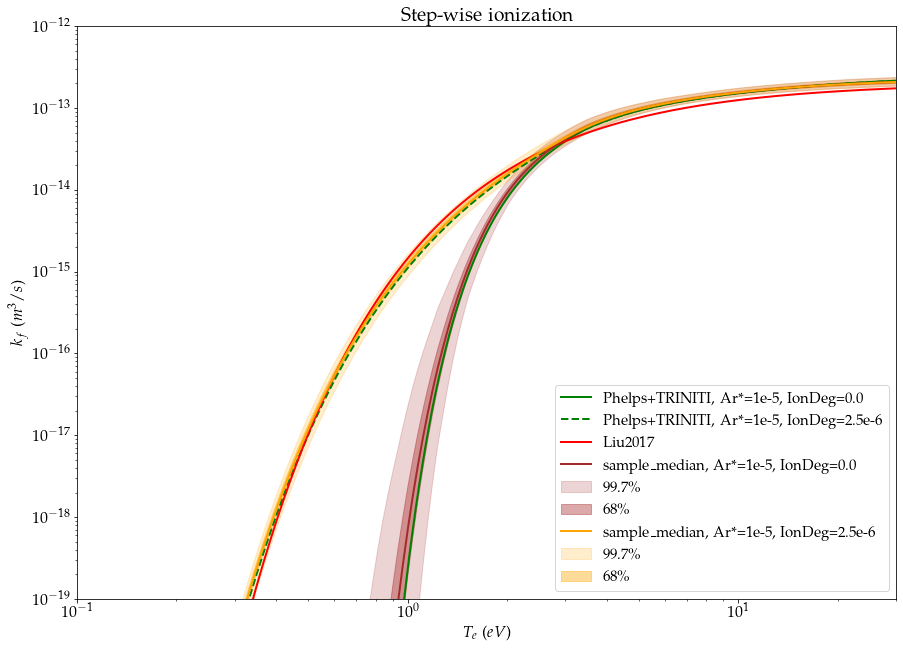

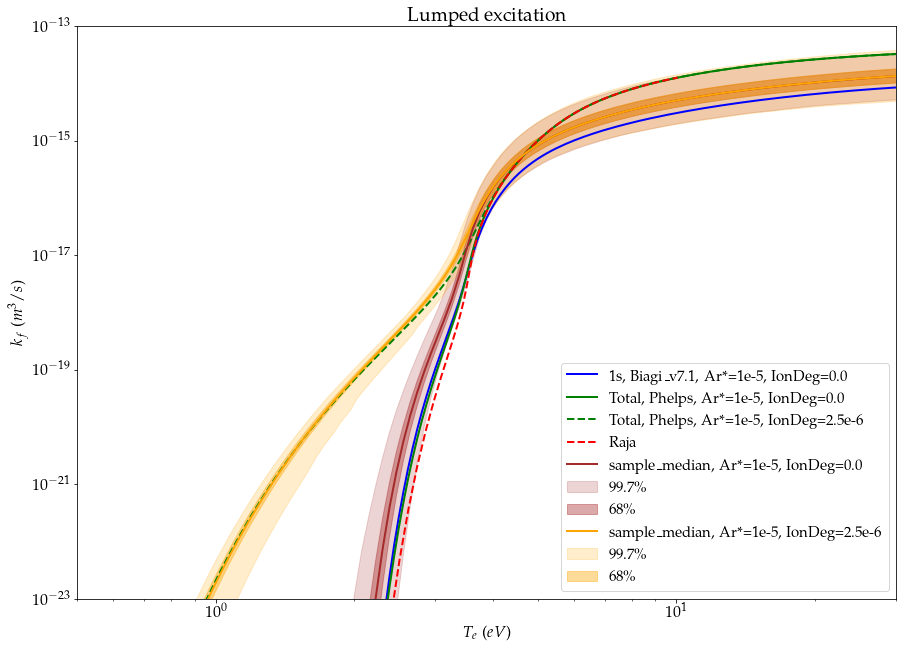

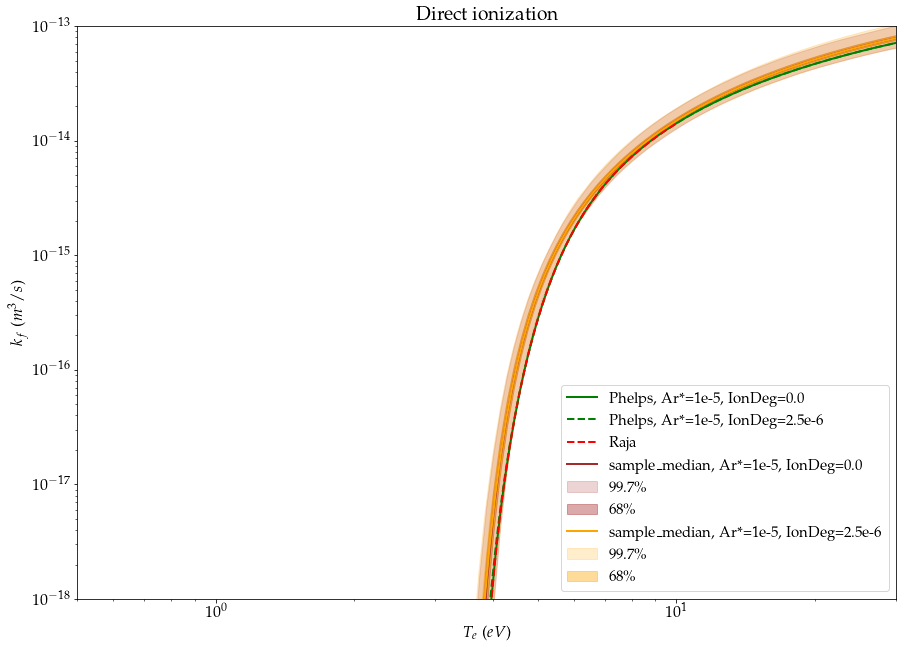

In [5]:
import input_writer as iw
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})
colors = ['b','g','darkred','c','mediumpurple','tomato']

Nsample = 7200
sig1 = int(0.5 * (1.0 - 0.68) * Nsample)
sig3 = int(0.5 * (1.0 - 0.997) * Nsample)
median = int(0.5 * Nsample)
N300 = 200

# Ue300 = np.fromfile('./glow-discharge/data-zero-ion-deg/reaction300K.Ue.dat')
# Te300 = Ue300 / 1.5
# fID = open('./glow-discharge/data-zero-ion-deg/reaction300K.Te.dat','w+')
# Te300.tofile(fID)
# fID.close()
Te300 = np.fromfile('./glow-discharge/data-zero-ion-deg/reaction300K.Te.dat')
Te300 = np.reshape(Te300,[Nsample,N300])

step_ion300 = np.fromfile('./glow-discharge/data-zero-ion-deg/reaction300K.step_ion.dat')
step_ion300 = np.reshape(step_ion300,[Nsample,N300])
step_ion_sort = np.copy(step_ion300)
step_ion_sort.sort(axis = 0)

ion300 = np.fromfile('./glow-discharge/data-zero-ion-deg/reaction300K.ion.dat')
ion300 = np.reshape(ion300,[Nsample,N300])
ion_sort = np.copy(ion300)
ion_sort.sort(axis = 0)

excite300 = np.fromfile('./glow-discharge/data-zero-ion-deg/reaction300K.excite.dat')
excite300 = np.reshape(excite300,[int(len(excite300)/14/N300),14,N300])

excite_sum = np.zeros([excite300.shape[0], N300])
for k in range(4):
    excite_sum += np.squeeze(excite300[:,k,:])
excite_sort = np.copy(excite_sum)
excite_sort.sort(axis = 0)

# fID = open('./glow-discharge/data-zero-ion-deg/reaction300K.excite.1s_lumped.dat','w+')
# excite_sum.tofile(fID)
# fID.close()

# Ue_ion = np.fromfile('./glow-discharge/data-ion-deg-2.5e-6/reaction300K.Ue.dat')
# Te_ion = Ue_ion / 1.5
# fID = open('./glow-discharge/data-ion-deg-2.5e-6/reaction300K.Te.dat','w+')
# Te_ion.tofile(fID)
# fID.close()
Te_ion = np.fromfile('./glow-discharge/data-ion-deg-2.5e-6/reaction300K.Te.dat')
Te_ion = np.reshape(Te_ion,[Nsample,N300])

step_ion_ion = np.fromfile('./glow-discharge/data-ion-deg-2.5e-6/reaction300K.step_ion.dat')
step_ion_ion = np.reshape(step_ion_ion,[Nsample,N300])
step_ion_ion_sort = np.copy(step_ion_ion)
step_ion_ion_sort.sort(axis = 0)

ion_ion = np.fromfile('./glow-discharge/data-ion-deg-2.5e-6/reaction300K.ion.dat')
ion_ion = np.reshape(ion_ion,[Nsample,N300])
ion_ion_sort = np.copy(ion_ion)
ion_ion_sort.sort(axis = 0)

excite_ion = np.fromfile('./glow-discharge/data-ion-deg-2.5e-6/reaction300K.excite.dat')
excite_ion = np.reshape(excite_ion,[int(len(excite_ion)/14/N300),14,N300])

excite_ion_sum = np.zeros([excite_ion.shape[0], N300])
for k in range(4):
    excite_ion_sum += np.squeeze(excite_ion[:,k,:])
excite_ion_sort = np.copy(excite_ion_sum)
excite_ion_sort.sort(axis = 0)

# fID = open('./glow-discharge/data-ion-deg-2.5e-6/reaction300K.excite.1s_lumped.dat','w+')
# excite_ion_sum.tofile(fID)
# fID.close()

outputFilename = "./output/datasets/Biagi_v7.1+step.dat"
output = bolsigOutput(outputFilename)
Te0 = output.outputs[3].data[:,1] / 1.5
dataType = output.typeDictS2I['C2']
rateExcite0 = output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C6']
rateStepIon0 = output.outputs[dataType].data[:,1]

outputFilename = "./output/datasets/Phelps+step.dat"
output = bolsigOutput(outputFilename)
Te1 = output.outputs[3].data[:,1] / 1.5
dataType = output.typeDictS2I['C2']
rateExcite1 = output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C4']
rateStepIon1 = output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C3']
rateIon1 = output.outputs[dataType].data[:,1]

outputFilename = "./output/datasets/Phelps+step.nonzero_ion.dat"
output = bolsigOutput(outputFilename)
Te2 = output.outputs[3].data[:,1] / 1.5
dataType = output.typeDictS2I['C2']
rateExcite2 = output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C4']
rateStepIon2 = output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C3']
rateIon2 = output.outputs[dataType].data[:,1]




LiuStepIon = 2.05e-7 * np.exp(- 4.95 / Te1) * 1e-6

plt.figure(1)
# plt.loglog(Te0, rateExcite0,'-', color='r', linewidth=2.0, label='Excite, Biagiv7.1, Ar*=1e-5')
# plt.loglog(Te1, rateExcite1,'-', color='g', linewidth=2.0, label='Excite, Phelps, Ar*=1e-5')
plt.loglog(Te1, rateStepIon1,'-', color='g', linewidth=2.0, label='Phelps+TRINITI, Ar*=1e-5, IonDeg=0.0')
plt.loglog(Te2, rateStepIon2,'--', color='g', linewidth=2.0, label='Phelps+TRINITI, Ar*=1e-5, IonDeg=2.5e-6')
# plt.loglog(Te1, rateStepIon1,'-', color='b', linewidth=2.0, label='Step-wise, Ar*=1e-5')
plt.loglog(Te1, LiuStepIon,'-', color='r', linewidth=2.0, label='Liu2017')

plt.loglog(Te300[0], step_ion_sort[median,:],'-', color='brown', linewidth=2.0, label='sample_median, Ar*=1e-5, IonDeg=0.0')
plt.fill_between(Te300[0], step_ion_sort[-sig3,:], step_ion_sort[sig3,:], color='brown', alpha=0.2, label='99.7\%')
plt.fill_between(Te300[0], step_ion_sort[-sig1,:], step_ion_sort[sig1,:], color='brown', alpha=0.4, label='68\%')

plt.loglog(Te_ion[0], step_ion_ion_sort[median,:],'-', color='orange', linewidth=2.0, label='sample_median, Ar*=1e-5, IonDeg=2.5e-6')
plt.fill_between(Te_ion[0], step_ion_ion_sort[-sig3,:], step_ion_ion_sort[sig3,:], color='orange', alpha=0.2, label='99.7\%')
plt.fill_between(Te_ion[0], step_ion_ion_sort[-sig1,:], step_ion_ion_sort[sig1,:], color='orange', alpha=0.4, label='68\%')

plt.title('Step-wise ionization')
plt.xlabel('$T_e$ ($eV$)')
plt.ylabel('$k_f$ ($m^3/s$)')
plt.xlim([0.1, 30])
plt.ylim([1e-19, 1e-12])
plt.tight_layout()
fig = plt.gcf()
fig.set_size_inches(15, 12)
plt.legend(loc='lower right', prop={'size': 15})

fig.savefig("./step-wise.comparison.pdf", dpi=1200)

plt.figure(2)
plt.loglog(Te0, rateExcite0,'-', color='b', linewidth=2.0, label='1s, Biagi_v7.1, Ar*=1e-5, IonDeg=0.0')
plt.loglog(Te1, rateExcite1,'-', color='g', linewidth=2.0, label='Total, Phelps, Ar*=1e-5, IonDeg=0.0')
plt.loglog(Te2, rateExcite2,'--', color='g', linewidth=2.0, label='Total, Phelps, Ar*=1e-5, IonDeg=2.5e-6')
plt.loglog(Raja_excite[:,0], Raja_excite[:,1],'--', color='r', linewidth=2.0, label='Raja')

# for k in range(Nsample):
#     plt.loglog(Te300[k], excite_sum[k],'-','orange',alpha=0.2)
plt.loglog(Te300[0], excite_sort[median,:],'-', color='brown', linewidth=2.0, label='sample_median, Ar*=1e-5, IonDeg=0.0')
plt.fill_between(Te300[0], excite_sort[-sig3,:], excite_sort[sig3,:], color='brown', alpha=0.2, label='99.7\%')
plt.fill_between(Te300[0], excite_sort[-sig1,:], excite_sort[sig1,:], color='brown', alpha=0.4, label='68\%')

plt.loglog(Te_ion[0], excite_ion_sort[median,:],'-', color='orange', linewidth=2.0, label='sample_median, Ar*=1e-5, IonDeg=2.5e-6')
plt.fill_between(Te_ion[0], excite_ion_sort[-sig3,:], excite_ion_sort[sig3,:], color='orange', alpha=0.2, label='99.7\%')
plt.fill_between(Te_ion[0], excite_ion_sort[-sig1,:], excite_ion_sort[sig1,:], color='orange', alpha=0.4, label='68\%')

plt.title('Lumped excitation')
plt.xlabel('$T_e$ ($eV$)')
plt.ylabel('$k_f$ ($m^3/s$)')
plt.xlim([0.5, 30])
plt.ylim([1e-23, 1e-13])
plt.tight_layout()
plt.legend(loc='lower right', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(15, 12)

fig.savefig("./lumped_excitation.comparison.pdf", dpi=1200)

plt.figure(3)
plt.loglog(Te1, rateIon1,'-', color='g', linewidth=2.0, label='Phelps, Ar*=1e-5, IonDeg=0.0')
plt.loglog(Te2, rateIon2,'--', color='g', linewidth=2.0, label='Phelps, Ar*=1e-5, IonDeg=2.5e-6')
plt.loglog(Raja_ion[:,0], Raja_ion[:,1],'--r', linewidth=2.0, label='Raja')

plt.loglog(Te300[0], ion_sort[median,:],'-', color='brown', linewidth=2.0, label='sample_median, Ar*=1e-5, IonDeg=0.0')
plt.fill_between(Te300[0], ion_sort[-sig3,:], ion_sort[sig3,:], color='brown', alpha=0.2, label='99.7\%')
plt.fill_between(Te300[0], ion_sort[-sig1,:], ion_sort[sig1,:], color='brown', alpha=0.4, label='68\%')

plt.loglog(Te_ion[0], ion_ion_sort[median,:],'-', color='orange', linewidth=2.0, label='sample_median, Ar*=1e-5, IonDeg=2.5e-6')
plt.fill_between(Te_ion[0], ion_ion_sort[-sig3,:], ion_ion_sort[sig3,:], color='orange', alpha=0.2, label='99.7\%')
plt.fill_between(Te_ion[0], ion_ion_sort[-sig1,:], ion_ion_sort[sig1,:], color='orange', alpha=0.4, label='68\%')

plt.title('Direct ionization')
plt.xlabel('$T_e$ ($eV$)')
plt.ylabel('$k_f$ ($m^3/s$)')
plt.xlim([0.5, 30])
plt.ylim([1e-18, 1e-13])
plt.tight_layout()
plt.legend(loc='lower right', prop={'size': 15})
fig = plt.gcf()
fig.set_size_inches(15, 12)

fig.savefig("./ionization.comparison.pdf", dpi=1200)